## Imputing missing Light and Noise values
Run KMeans clustering algorithm to group data into room types based on 3 feature (temperature, humidity, CO2). Using elbow method to find reasonable number of clusters.

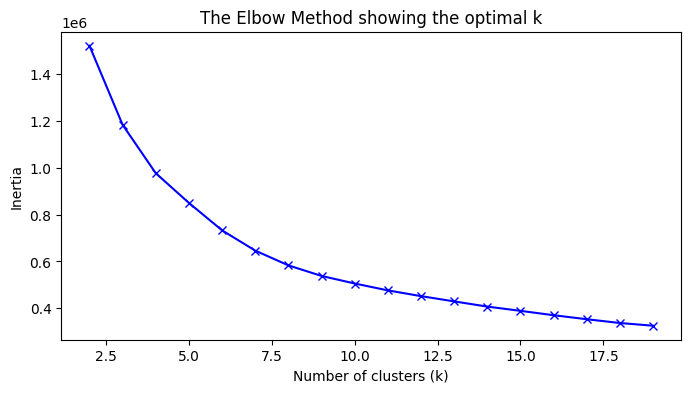

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor



# --- 1. LOAD DATA --- 
# TODO:use full combined dataset after its done

# Load our 3 different datasets
df1 = pd.read_csv('../../data/raw/1_room_measurements.csv')
df1 = df1.rename(columns={'sensorId': 'sensor_id', 'CO2': 'co2', 'room': 'roomId'})

df2 = pd.read_csv('../../data/interim/keti_1min_resampled.csv', dtype={'room': str})
df2 = df2.rename(columns={'room': 'roomId'})

df3 = pd.read_csv('../../data/raw/room_conditions.csv')
df3 = df3.rename(columns={
    'id': 'roomId', 'Temperature': 'temperature', 'Humidity': 'humidity',
    'Light': 'light', 'CO2': 'co2', 'date': 'timestamp'
})

# List the columns we want at the very end
final_cols = ['roomId', 'timestamp', 'temperature', 'humidity', 'co2', 'light', 'noise']

# If a dataset is missing a column, add it as NaN so we can glue them
for d in [df1, df2, df3]:
    for col in final_cols:
        if col not in d.columns:
            d[col] = np.nan

# Glue all 3 datasets together into one big table
combined_df = pd.concat([df1[final_cols], df2[final_cols], df3[final_cols]], ignore_index=True)


# We use these 3 to group similar rows together
anchors = ['temperature', 'humidity', 'co2']

# KMeans hates missing values, so we temporarily fill them with the median TODO: this should be handled correclty in the analysis of full final dataset
temp_fill = SimpleImputer(strategy='median').fit_transform(combined_df[anchors])

# Scale the data (Standardize) so CO2 doesn't drown out Temperature
scaled_data = StandardScaler().fit_transform(temp_fill)


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 20) # Test from 2 to 20 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data) # Use your scaled anchor data
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()



I picked 6 clusters because that's where the improvement starts to level off, so adding more would just make the model more complex without actually helping much. 

## Impute Light and Noise
We utilized an IterativeImputer with an ExtraTreesRegressor backend. Unlike standard linear MICE, ExtraTrees captures non-linear interactions between variables (e.g., $CO_2$ spikes as a proxy for occupancy affecting light). For "dead" clusters, where `Light` or `Noise` are 100% missing, we applied a Global Median fallback. This is a deliberate design choice to handle extreme data sparsity, without at least some local ground truth, a model cannot statistically converge on a meaningful correlation, and a robust central tendency (median) is used to prevent model bias.

Processing Cluster 0...
  ✅  Cluster 0: All sensors present. Running full smart imputation.
Processing Cluster 1...
  ✅  Cluster 1: All sensors present. Running full smart imputation.
Processing Cluster 2...
  ✅  Cluster 2: All sensors present. Running full smart imputation.
Processing Cluster 3...
  ✅  Cluster 3: All sensors present. Running full smart imputation.
Processing Cluster 4...
  ✅  Cluster 4: All sensors present. Running full smart imputation.
Processing Cluster 5...
  ⚠️  Cluster 5: Skipping sensor(s) ['light'] (100% missing in this cluster)

--- Final Imputation Complete ---
Missing values remaining: 0

Top of your new dataset:
      roomId                 timestamp  temperature  humidity    co2  \
0  Room 2.12  2025-09-15T00:00:03.000Z         24.4      59.0  413.0   
1  Room 2.12  2025-09-15T00:05:05.000Z         24.5      59.0  418.0   
2  Room 2.12  2025-09-15T00:10:08.000Z         24.4      59.0  421.0   
3  Room 2.12  2025-09-15T00:15:11.000Z         24.4      59.0 

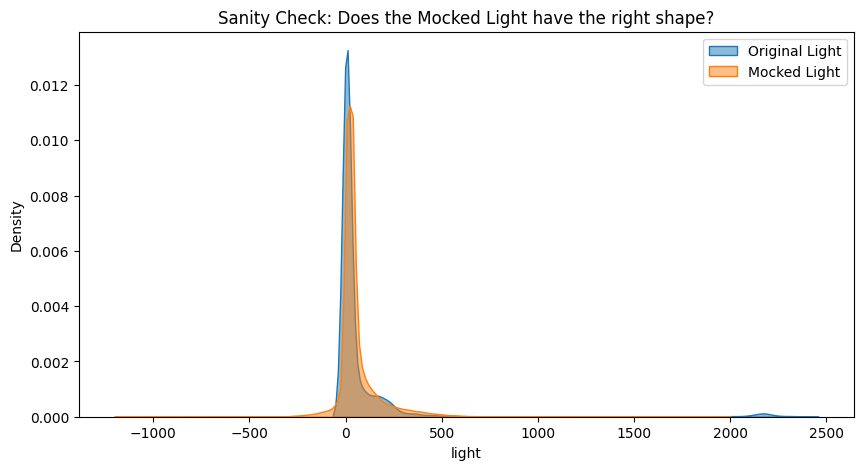

In [24]:
# This class modifies ExtraTreesRegressor by teaching the Forest how to calculate 
# uncertainty (std).
class SmartForest(ExtraTreesRegressor):
    def predict(self, X, return_std=False):
        if not return_std:
            return super().predict(X)
        # We ask every tree in the forest for its guess
        all_preds = np.stack([t.predict(X) for t in self.estimators_])
        # Return the average and the "disagreement" (standard deviation)
        return np.mean(all_preds, axis=0), np.std(all_preds, axis=0)

model_kmeans = KMeans(n_clusters=6, random_state=42)
combined_df['room_type'] = model_kmeans.fit_predict(scaled_data)

# --- 3. MOCKING LIGHT AND NOISE (STREAMLINED ROBUST LOOP) ---

imputed_chunks = []

# We go through every group found by KMeans
for room_id in sorted(combined_df['room_type'].unique()):
    print(f"Processing Cluster {room_id}...")
    
    # Get the rows for just this group
    chunk = combined_df[combined_df['room_type'] == room_id].copy()
    original_backup = chunk.copy()
    
    # Create the imputer
    mice = IterativeImputer(
        estimator=SmartForest(
            n_estimators=20, 
            max_depth=10, 
            min_samples_leaf=5, 
            random_state=42
        ),
        max_iter=3,
        sample_posterior=True, 
        n_nearest_features=5,
        random_state=42
    )
    
    # 1. Identify numeric columns (excluding the cluster label itself)
    numbers_only = chunk.select_dtypes(include=[np.number]).columns.tolist()
    if 'room_type' in numbers_only: numbers_only.remove('room_type')
    
    # 2. Identify which sensors are active vs. 100% missing in this cluster
    active_cols = [col for col in numbers_only if chunk[col].notna().any()]
    dropped_cols = list(set(numbers_only) - set(active_cols))
    
    # Printout to see exactly what is happening in each cluster
    if dropped_cols:
        print(f"  ⚠️  Cluster {room_id}: Skipping sensor(s) {dropped_cols} (100% missing in this cluster)")
    else:
        print(f"  ✅  Cluster {room_id}: All sensors present. Running full smart imputation.")
    
    # 3. Run the Imputation
    # (No 'if' check needed here because Temp, Hum, and CO2 are pre-filled)
    filled_data = mice.fit_transform(chunk[active_cols])
    temp_df = pd.DataFrame(filled_data, columns=active_cols, index=chunk.index)
    
    # --- PROTECTION: RESTORE THE ORIGINAL DATA ---
    # We only want the imputed Light and Noise. Everything else stays pure.
    for col in active_cols:
        if col in ['temperature', 'humidity', 'co2']:
            temp_df[col] = original_backup[col].values
            
    # Re-add text columns (roomId, timestamp) and any skipped sensors
    for col in chunk.columns:
        if col not in temp_df.columns:
            temp_df[col] = original_backup[col].values
    
    imputed_chunks.append(temp_df)

# --- 4. FINAL GLUE AND SAFETY NET ---

# Combine all the groups and sort them back into the original order
final_df = pd.concat(imputed_chunks).sort_index()

# THE SAFETY NET: Fill any sensors that were 100% dead in a cluster with the global median
final_df['light'] = final_df['light'].fillna(combined_df['light'].median())
final_df['noise'] = final_df['noise'].fillna(combined_df['noise'].median())

# Apply the final column order
final_df = final_df[final_cols]

print("\n--- Final Imputation Complete ---")
print(f"Missing values remaining: {final_df[['light', 'noise']].isna().sum().sum()}")

# --- 5. VISUAL CHECK ---

print("\nTop of your new dataset:")
print(final_df.head())

# Plot the distribution to check the 'texture' of the mocked data
plt.figure(figsize=(10, 5))
sns.kdeplot(combined_df['light'].dropna(), label='Original Light', fill=True, alpha=0.5)
sns.kdeplot(final_df.loc[combined_df['light'].isna(), 'light'], label='Mocked Light', fill=True, alpha=0.5)
plt.title('Sanity Check: Does the Mocked Light have the right shape?')
plt.legend()
plt.show()

## Variance check
Compare the standard deviation of original vs mocked `light` and `noise` to see if the synthetic values keep a similar spread.

In [25]:
#comparison std of light and noise
print("The standard deviation of the original light is:", combined_df['light'].std())
print("The standard deviation of the mocked light is:", final_df['light'].std())
print("The standard deviation of the original noise is:", combined_df['noise'].std())
print("The standard deviation of the mocked noise is:", final_df['noise'].std())

The standard deviation of the original light is: 308.84204593367286
The standard deviation of the mocked light is: 276.30479178558744
The standard deviation of the original noise is: 9.579405148798282
The standard deviation of the mocked noise is: 8.254701388282164
